In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def manual(X, Y):
    if len(X.shape) == 1:
        X = X.reshape(-1, 1)

    X_mat = np.column_stack((X, np.ones(len(X))))

    X_T = X_mat.T

    X_T_X = np.dot(X_T, X_mat)

    Inversa = np.linalg.inv(X_T_X)

    X_T_Y = np.dot(X_T, Y)
    W = np.dot(Inversa, X_T_Y)

    return W

1. PIB: MSE = 0.43215056726384027, MAE = 0.5330347249725854


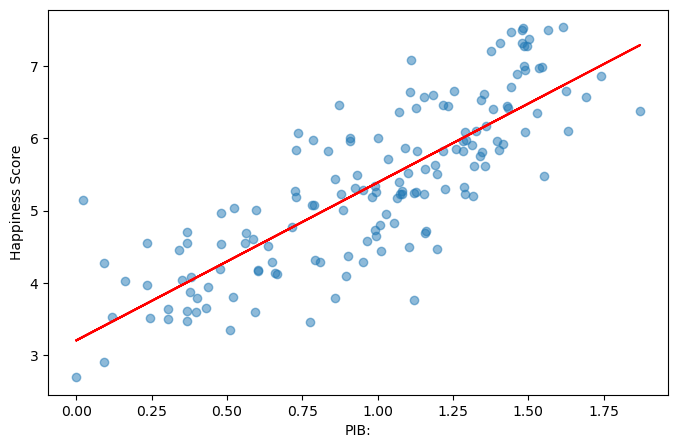

2. Familie: MSE = 0.5510199236253974, MAE = 0.6210254195971343


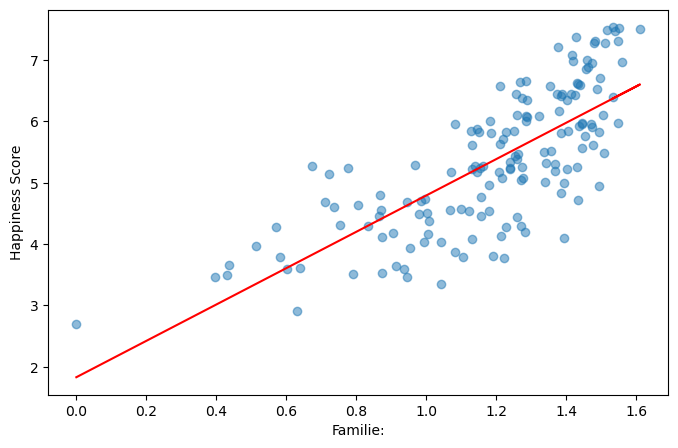

3. PIB + Liberatate: MSE = 0.4887143379010964, MAE = 0.574822475733187


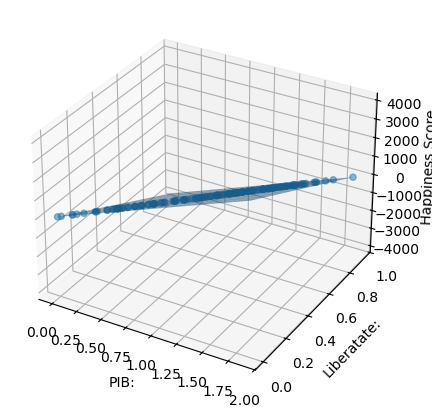

In [ ]:
# file_name = "resources/v1_world-happiness-report-2017.csv"
# file_name = "resources/v2_world-happiness-report-2017.csv"
file_name = "resources/v3_world-happiness-report-2017.csv"
df = pd.read_csv(file_name)

col_gdp = "Economy..GDP.per.Capita."
col_family = "Family"
col_freedom = "Freedom"
col_happiness = "Happiness.Score"

df = df.dropna(subset=[col_gdp, col_family, col_freedom, col_happiness])

Y = df[col_happiness].values

#PIB
X_gdp = df[col_gdp].values
X_family = df[col_family].values
X_freedom = df[col_freedom].values

""" Version 1 """
# w1, b1 = np.polyfit(X_gdp, Y, 1)
# w2, b2 = np.polyfit(X_family, Y, 1)
# X_multi = np.column_stack((X_gdp, X_freedom, np.ones(len(X_gdp))))
# result = np.linalg.lstsq(X_multi, Y, rcond=None)[0]

""" Version 2 """
w1, b1 = manual(X_gdp, Y)
w2, b2 = manual(X_family, Y)
X_multi = np.column_stack((X_gdp, X_freedom))
result = manual(X_multi, Y)

#PIB

Y_est_gdp = w1 * X_gdp + b1
mse1 = np.mean((Y - Y_est_gdp) ** 2)
mae1 = np.mean(np.abs(Y - Y_est_gdp))

#Familie

Y_est_family = w2 * X_family + b2
mse2 = np.mean((Y - Y_est_family) ** 2)
mae2 = np.mean(np.abs(Y - Y_est_family))

#PIB + Liberatate

w3_gdp = result[0]
w3_freedom = result[1]
b3 = result[2]

Y_est_multi = w3_gdp * X_gdp + w3_freedom * X_freedom + b3

mse3 = np.mean((Y - Y_est_multi) ** 2)
mae3 = np.mean(np.abs(Y - Y_est_multi))

print(f"1. PIB: MSE = {mse1}, MAE = {mae1}")
plt.figure(figsize=(8, 5))
plt.scatter(X_gdp, Y, alpha=0.5)
plt.plot(X_gdp, Y_est_gdp, color='red')
plt.xlabel("PIB:")
plt.ylabel("Happiness Score")
plt.show()

print(f"2. Familie: MSE = {mse2}, MAE = {mae2}")
plt.figure(figsize=(8, 5))
plt.scatter(X_family, Y, alpha=0.5)

if X_family.min() == X_family.max():
    print("All countries have the same family value.")
    plt.axhline(y=Y_est_family[0], color='red', linestyle='--')
else:
    plt.plot(X_family, Y_est_family, color='red')
plt.xlabel("Familie:")
plt.ylabel("Happiness Score")
plt.show()

print(f"3. PIB + Liberatate: MSE = {mse3}, MAE = {mae3}")
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_gdp, X_freedom, Y, alpha=0.5)
x_surf, y_surf = np.meshgrid(
    np.linspace(X_gdp.min(), X_gdp.max(), 10),
    np.linspace(X_freedom.min(), X_freedom.max(), 10)
)
z_surf = w3_gdp * x_surf + w3_freedom * y_surf + b3

ax.plot_surface(x_surf, y_surf, z_surf, alpha=0.5)
ax.set_xlabel("PIB:")
ax.set_ylabel("Liberatate:")
ax.set_zlabel("Happiness Score")
plt.show()